ファイルを読み込みます: G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data/combined_EyeCenterAngle_saccade_analysis_15_4567815161718_umap_nofreq.csv
,区切りファイルとして読み込みます
データ読み込み完了: 177行, 24列
特徴量として使用: 23列
データの標準化を実行中...
標準化完了
UMAPによる次元削減を実行中...


c:\Users\user\anaconda3\envs\mci\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\user\anaconda3\envs\mci\lib\site-packages\umap\umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


UMAP次元削減完了
すべてのポイントにIDを表示中...
ラベルの重なりを調整してすべてのポイントにIDを表示中...
ラベルの重なり回避機能が使えません。pip install adjustTextでインストールできます。
すべてのIDを表示したプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_only_all_ids.png
ラベルの重なりを調整したプロットを保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_only_all_ids_adjusted.png
解析結果をCSVに保存しました: G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result\umap_only_data.csv
処理完了!


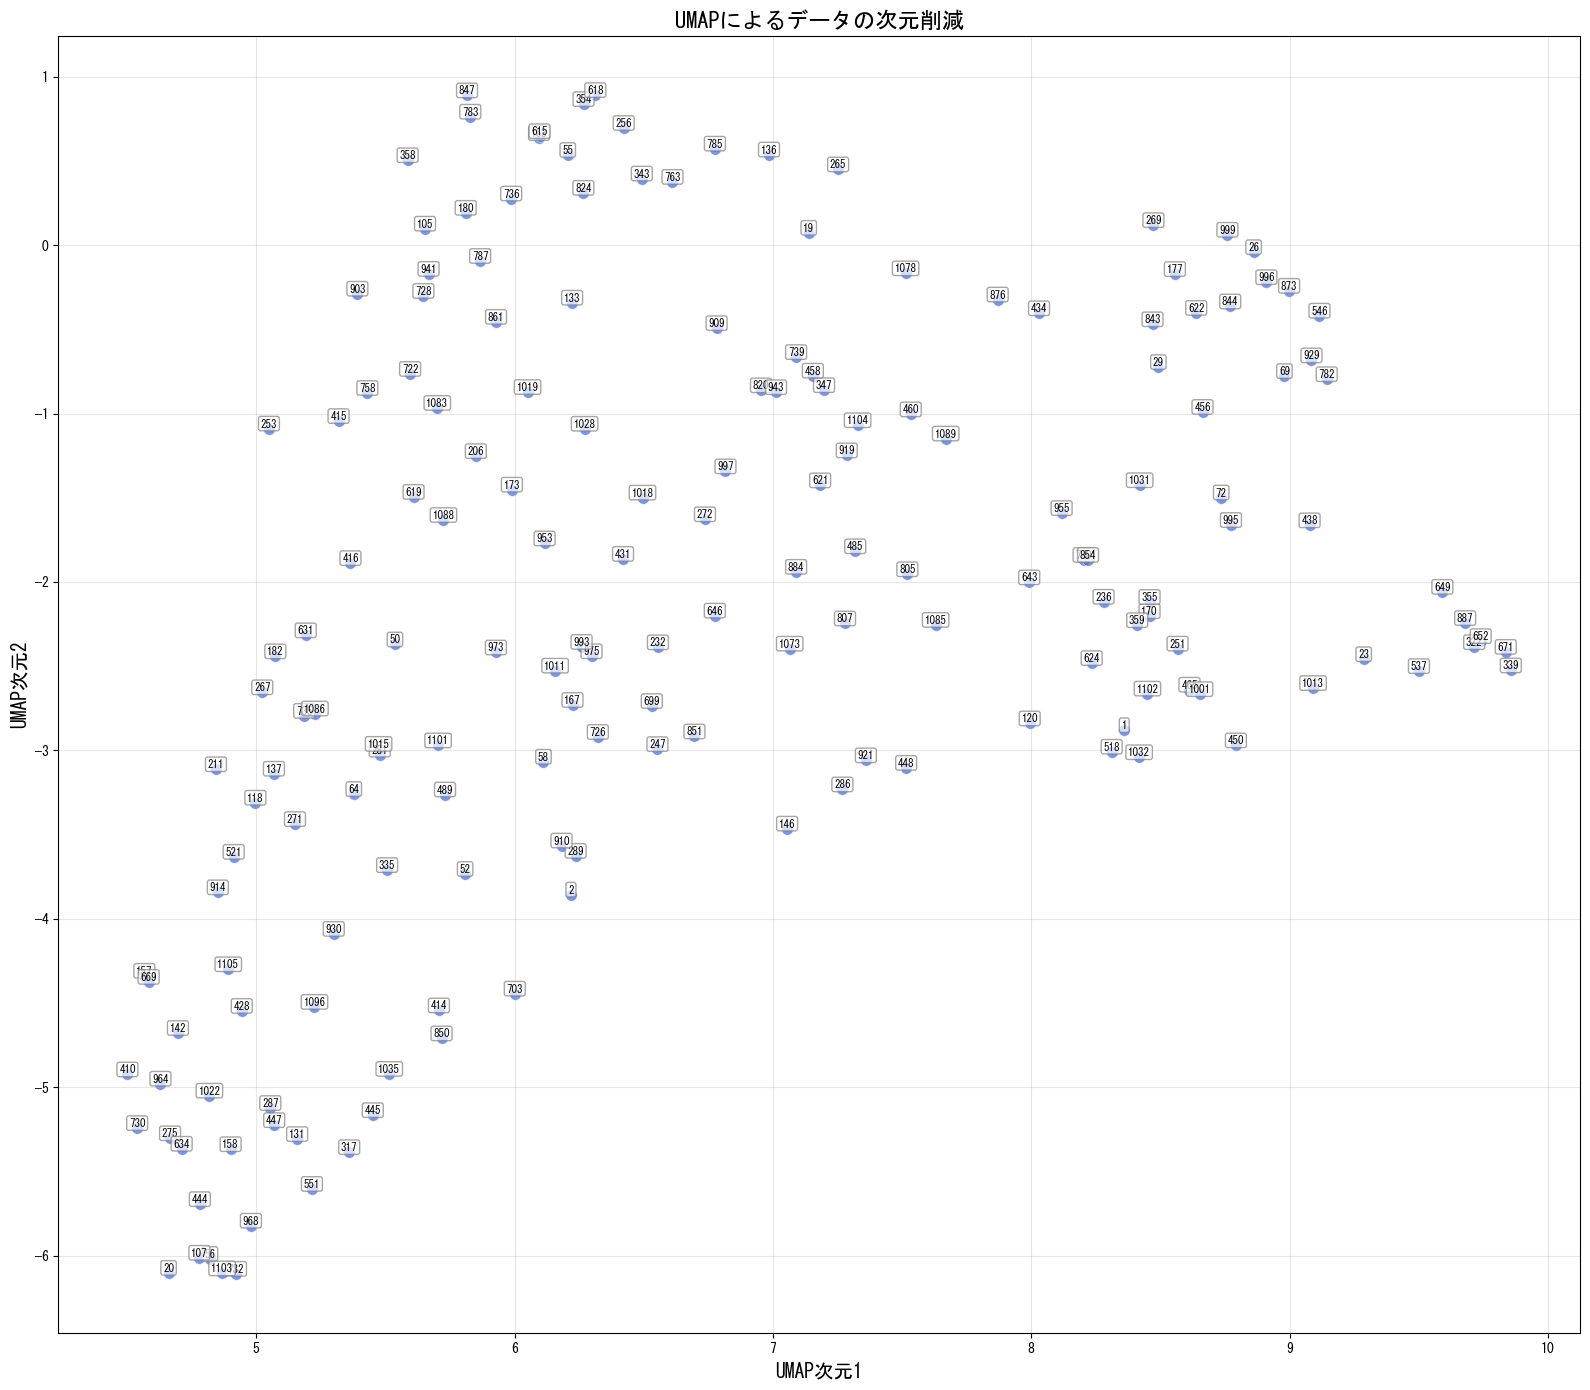

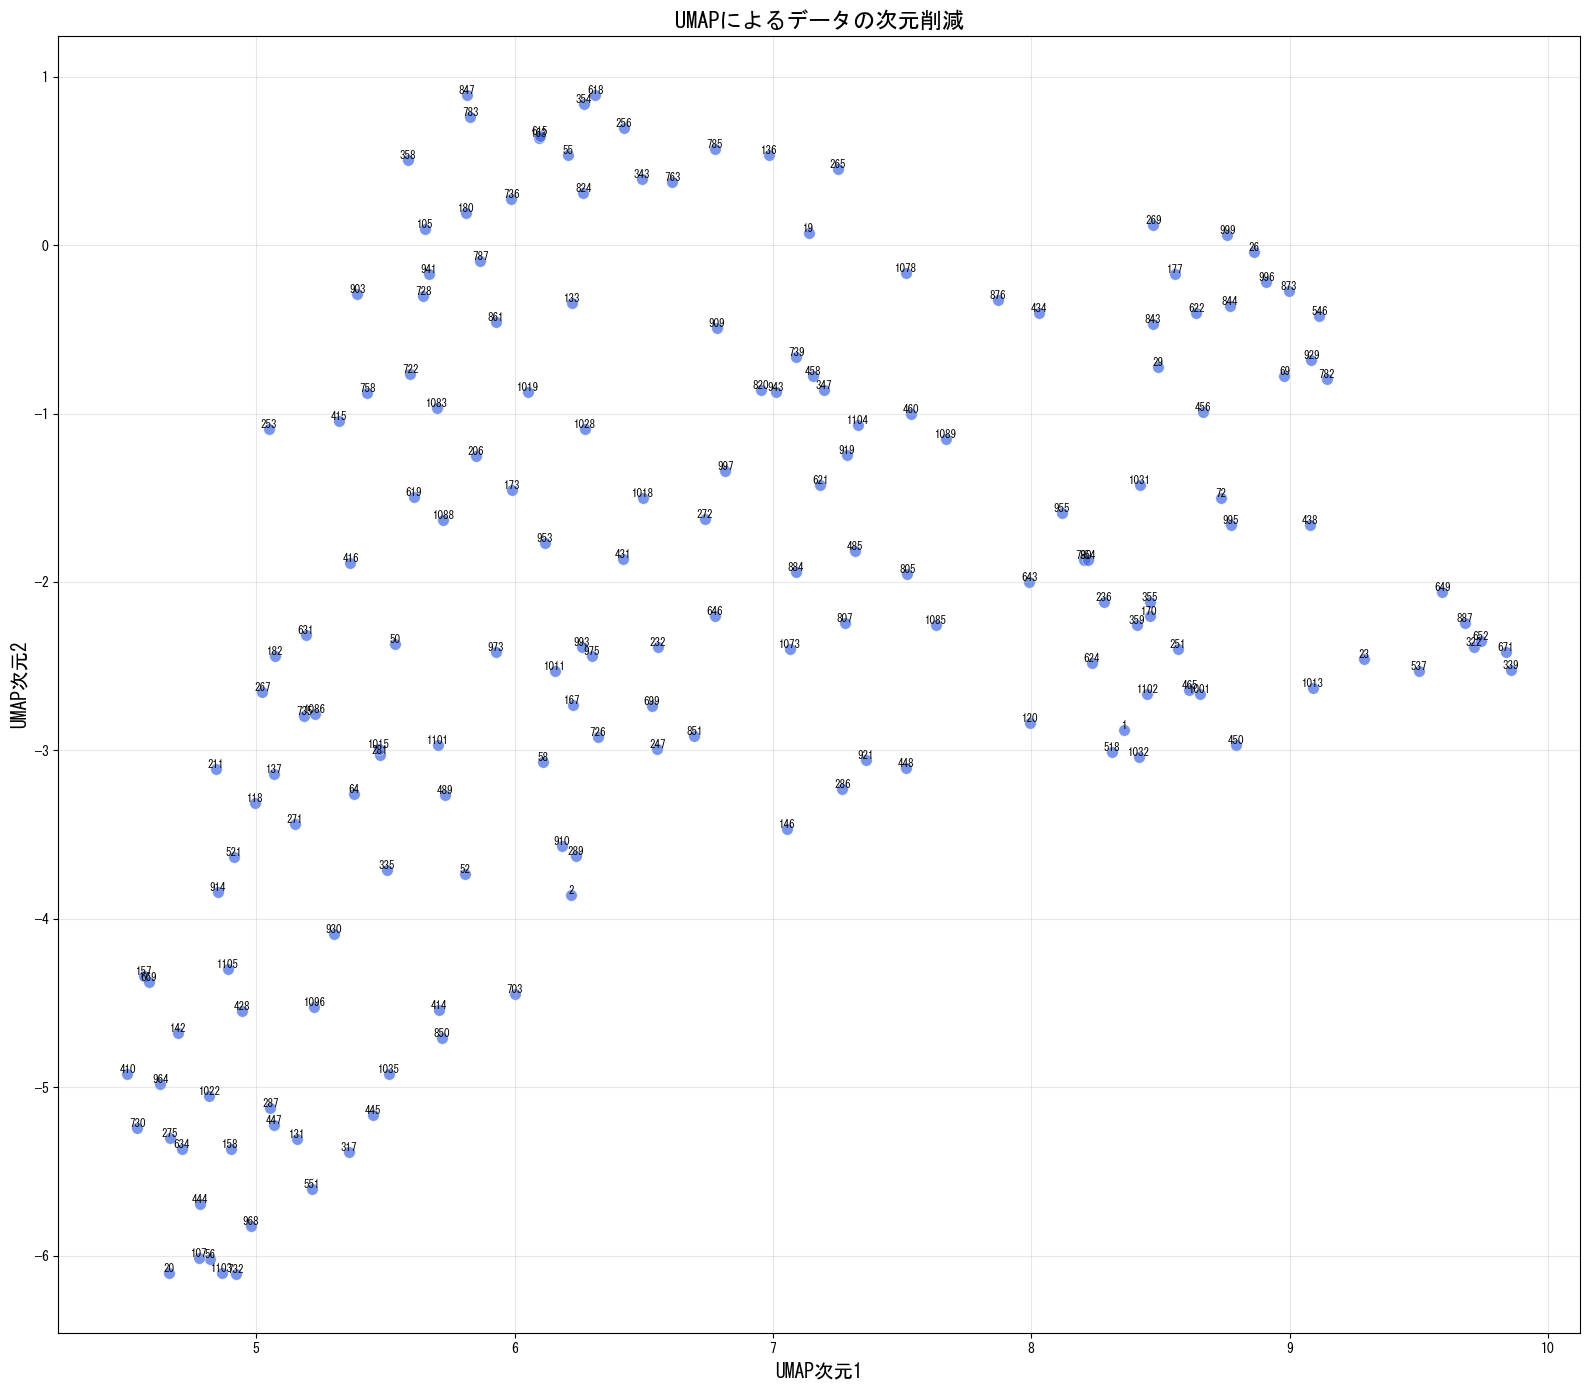

In [1]:
%matplotlib inline
# 対話的な表示が必要な場合は %matplotlib widget に変更してください

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib
from sklearn.preprocessing import StandardScaler
from umap import UMAP
import os

# 日本語フォント設定（必要に応じて）
try:
    import matplotlib.font_manager as fm
    font_path = 'C:/Windows/Fonts/msgothic.ttc'  # Windowsの場合のMSゴシック
    if os.path.exists(font_path):
        prop = fm.FontProperties(fname=font_path)
        matplotlib.rcParams['font.family'] = prop.get_name()
except Exception:
    pass  # フォント設定に失敗しても処理を続行

# ファイルパスの設定
path = "G:/共有ドライブ/GAP_長寿研/user/iwamoto/視線の動きの俊敏さ/data"
file_path = f"{path}/combined_EyeCenterAngle_saccade_analysis_15_4567815161718_umap_nofreq.csv"

print(f"ファイルを読み込みます: {file_path}")

# ファイルの読み込みと前処理
try:
    # 区切り文字を検出
    with open(file_path, 'r') as f:
        first_line = f.readline().strip()
        
    separator = '\t' if '\t' in first_line else (',' if ',' in first_line else '\t')
    print(f"{separator}区切りファイルとして読み込みます")
    
    # CSVファイルの読み込み
    df = pd.read_csv(file_path, sep=separator)
    print(f"データ読み込み完了: {df.shape[0]}行, {df.shape[1]}列")
    
    # 列が1つだけの場合の処理
    if df.shape[1] == 1:
        print("列が1つだけです。カンマ区切りでの再分割を試みます")
        first_col_name = df.columns[0]
        if ',' in str(df[first_col_name].iloc[0]):
            temp_df = df[first_col_name].str.split(',', expand=True)
            headers = temp_df.iloc[0]
            temp_df = temp_df.iloc[1:]
            temp_df.columns = headers
            df = temp_df
            print("カンマ区切りで再分割しました")
    
    # 数値列に変換
    for col in df.columns:
        if col not in ['freq', 'power_spectrum', 'InspectionDateAndId']:
            try:
                df[col] = pd.to_numeric(df[col])
            except:
                pass
    
    # 数値列のみを選択
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    print(f"特徴量として使用: {len(numeric_cols)}列")
    
    # 特徴量が空の場合はエラー
    if not numeric_cols:
        raise ValueError("数値特徴量が見つかりません")
    
    # 数値データを抽出
    X = df[numeric_cols].copy()
    X = X.fillna(X.mean())  # 欠損値を平均値で補完
    
    # 標準化
    print("データの標準化を実行中...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print("標準化完了")
    
    # UMAP次元削減
    print("UMAPによる次元削減を実行中...")
    reducer = UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_scaled)
    print("UMAP次元削減完了")
    
    # UMAP座標をデータフレームに追加
    df['umap_x'] = embedding[:, 0]
    df['umap_y'] = embedding[:, 1]
    
except FileNotFoundError:
    print(f"エラー: ファイル '{file_path}' が見つかりません。")
    raise
except Exception as e:
    print(f"エラー: {str(e)}")
    raise

# ========================
# すべてのポイントにIDを表示する関数（クラスタリングなし）
# ========================

def plot_all_points_with_ids(df, embedding, id_column='InspectionDateAndId',
                             id_type='suffix', fontsize=8, point_size=70,
                             color='royalblue', alpha=0.7):
    """
    UMAPの結果にすべてのポイントのIDを表示する関数（クラスタリングなし）
    
    Parameters:
    -----------
    df : pandas.DataFrame
        データフレーム（IDを含む）
    embedding : numpy.ndarray
        UMAPによる2次元埋め込み座標
    id_column : str
        ID列の列名
    id_type : str
        'full'=完全なID, 'suffix'=末尾のみ, 'prefix'=先頭のみ
    fontsize : int
        IDのフォントサイズ
    point_size : int
        ポイントのサイズ
    color : str
        点の色
    alpha : float
        ポイントの透明度
    
    Returns:
    --------
    fig : matplotlib.figure.Figure
        作成された図のオブジェクト
    ax : matplotlib.axes.Axes
        作成された軸のオブジェクト
    """
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # ポイントをプロット（クラスタリングなしなので単色）
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=color, 
        s=point_size,
        alpha=alpha,
        edgecolor='white',
        linewidth=0.5
    )
    
    # IDを表示
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # IDの処理（表示方法に応じて）
        if id_type == 'suffix' and '_' in full_id:
            # '_'で区切られた末尾の部分を表示
            display_id = full_id.split('_')[-1]
        elif id_type == 'prefix' and '_' in full_id:
            # '_'で区切られた先頭の部分を表示
            display_id = full_id.split('_')[0]
        else:
            # 完全なIDを表示
            display_id = full_id
        
        # テキスト追加
        ax.text(
            x, y, 
            display_id,
            fontsize=fontsize,
            ha='center',  # 水平方向の位置揃え
            va='bottom',  # 垂直方向の位置揃え
            bbox=dict(
                boxstyle="round,pad=0.2",
                fc="white",
                ec="gray",
                alpha=0.7
            )
        )
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title('UMAPによるデータの次元削減', fontsize=16)
    
    # グリッドとレイアウト
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# ========================
# より高度なバージョン - ラベルの重なりを制御
# ========================

def plot_all_points_with_non_overlapping_ids(df, embedding, id_column='InspectionDateAndId',
                                             color='royalblue'):
    """
    すべてのポイントにIDを表示し、ラベルの重なりを最小化する（クラスタリングなし）
    """
    try:
        # adjust_textライブラリのインポートを試みる
        from adjustText import adjust_text
        has_adjust_text = True
    except ImportError:
        print("Warning: adjustTextライブラリがインストールされていません。")
        print("ラベルの重なり回避機能が使えません。pip install adjustTextでインストールできます。")
        has_adjust_text = False
    
    # 図の作成
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # ポイントをプロット（単色）
    scatter = ax.scatter(
        embedding[:, 0], 
        embedding[:, 1], 
        c=color, 
        s=70,
        alpha=0.7,
        edgecolor='white',
        linewidth=0.5
    )
    
    # テキスト収集（ラベルの重なりを調整するため）
    texts = []
    for i, (x, y) in enumerate(embedding):
        full_id = str(df.iloc[i][id_column])
        
        # '_'で区切られた末尾の部分を表示
        if '_' in full_id:
            display_id = full_id.split('_')[-1]
        else:
            display_id = full_id
        
        # テキスト追加
        text = ax.text(
            x, y, 
            display_id,
            fontsize=8,
            ha='center',
            va='bottom'
        )
        texts.append(text)
    
    # ラベルの重なりを調整
    if has_adjust_text:
        adjust_text(
            texts,
            force_points=0.2,
            force_text=0.5,
            expand_points=(1.2, 1.2),
            expand_text=(1.2, 1.2),
            arrowprops=dict(arrowstyle="-", color="gray", alpha=0.6, lw=0.5)
        )
    
    # 軸ラベルとタイトル
    ax.set_xlabel('UMAP次元1', fontsize=14)
    ax.set_ylabel('UMAP次元2', fontsize=14)
    ax.set_title('UMAPによるデータの次元削減', fontsize=16)
    
    # グリッドとレイアウト
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    
    return fig, ax

# ========================
# 処理の実行
# ========================

# 1. 通常バージョン - すべてのポイントに直接IDを表示
print("すべてのポイントにIDを表示中...")
fig1, ax1 = plot_all_points_with_ids(
    df, embedding,
    id_type='suffix',  # 'suffix', 'prefix', 'full' から選択
    fontsize=8,        # IDのフォントサイズ
    point_size=70,     # ポイントのサイズ
    color='royalblue', # ポイントの色
    alpha=0.7          # ポイントの透明度
)

# 2. 高度なバージョン - ラベルの重なりを最小化
print("ラベルの重なりを調整してすべてのポイントにIDを表示中...")
fig2, ax2 = plot_all_points_with_non_overlapping_ids(df, embedding)

# ========================
# 結果の保存
# ========================

# 保存先の設定
result_path = r"G:\共有ドライブ\GAP_長寿研\user\iwamoto\視線の動きの俊敏さ\result"
os.makedirs(result_path, exist_ok=True)

# 1. 通常バージョンの保存
normal_plot_path = os.path.join(result_path, "umap_only_all_ids.png")
fig1.savefig(normal_plot_path, dpi=300, bbox_inches='tight')
print(f"すべてのIDを表示したプロットを保存しました: {normal_plot_path}")

# 2. 高度なバージョンの保存（adjustTextがある場合）
advanced_plot_path = os.path.join(result_path, "umap_only_all_ids_adjusted.png")
fig2.savefig(advanced_plot_path, dpi=300, bbox_inches='tight')
print(f"ラベルの重なりを調整したプロットを保存しました: {advanced_plot_path}")

# 3. CSV結果の保存 - UMAP座標を含む
csv_file_path = os.path.join(result_path, "umap_only_data.csv")
df.to_csv(csv_file_path, index=False)
print(f"解析結果をCSVに保存しました: {csv_file_path}")

print("処理完了!")

In [2]:
conda install adjustText

Channels:
 - defaults
Platform: win-64
Solving environment: ...working... failed

Note: you may need to restart the kernel to use updated packages.



PackagesNotFoundError: The following packages are not available from current channels:

  - adjusttext

Current channels:

  - defaults
  - https://repo.anaconda.com/pkgs/main
  - https://repo.anaconda.com/pkgs/r
  - https://repo.anaconda.com/pkgs/msys2

To search for alternate channels that may provide the conda package you're
looking for, navigate to

    https://anaconda.org

and use the search bar at the top of the page.


